In [ ]:
import os
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

api_key_FRED="72f7955268d6a65a486d6ca126771837"

FRED_key = os.getenv('api_key_FRED')
api_key = FRED_key

# prompt_name = 'StonaV2_GPT35_0301'

prompt_name = 'StonaV2_GPT4_0613'

# prompt_name = 'StonaV2_GPT35_0613'

# prompt_name = 'anderson_V2_GPT35_0613'

# prompt_name = 'raw_GPT4_0613'
# prompt_name = 'raw_GPT35_0613'

## Download federal funds rate data

In [2]:
def get_fred_data(id_data: str) -> pd.DataFrame:
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={id_data}&api_key={api_key}&file_type=json'
    response = requests.get(url)

    # Check to make sure the request was successful
    if response.status_code != 200:
        raise Exception('Failed to get data:', response.status_code)
    else:
        # Convert the response to a dictionary
        data = response.json()

        # Extract the 'observations' field from the data
        observations = data['observations']

        # Create a pandas DataFrame from the observations
        df = pd.DataFrame(observations)

        return df

In [3]:
def get_diff_federal_funds() -> pd.DataFrame:
    df_upper = get_fred_data('DFEDTARL')
    df_upper['date'] = pd.to_datetime(df_upper['date'])
    df_upper['value'] = df_upper['value'].astype(float)
    return df_upper

In [4]:
# Get Shadow Rates and fed funds CBOT 30-day fed funds 1 month continuation future.
# Follow https://www.atlantafed.org/cqer/research/wu-xia-shadow-federal-funds-rate for more explanation

def get_shadow() -> pd.DataFrame:
    df = pd.read_excel(r'.\\kpi\\WuXiaShadowRate.xlsx').iloc[:,[0,1,2]]
    df.columns = ['data','fed_funds','shadow_rate']
    df['data'] = pd.to_datetime(df['data'])
    df.set_index('data',inplace=True)
    return df[['shadow_rate']].dropna()

def get_fed_cont(months: int) -> pd.DataFrame:
    df = pd.read_parquet(rf'.\\kpi\\ffc{months}.parquet').iloc[:,[0,1,2]]
    return df[['IMP_YIELD']].dropna()

## Statements

In [5]:
file_name_statment = f'statements_{prompt_name}'

df_statment = pd.read_excel(f'{file_name_statment}.xlsx')

grade_mapping = {
'dovish': -1,
'1. dovish': -1,
'1': -1,

'mostly dovish': -0.5,
'2. mostly dovish': -0.5,
'2': -0.5,

'mostly neutral': 0,
'neutral': 0,
'3. neutral': 0,
'3' : 0,

'mostly hawkish': 0.5,
'4. mostly hawkish': 0.5,
'4' : 0.5,

'hawkish': 1,
'5. hawkish': 1,
'5':1,
}

# Use map function to map grades
df_statment['classification'] = df_statment['classification'].astype(str)
df_statment['classification'] = df_statment['classification'].str.lower().map(grade_mapping)
df_statment['data'] = pd.to_datetime(df_statment['data'])
# df_minutas['last_update'] = pd.to_datetime(df_minutas['last_update'].apply(lambda x: x[0:10]))


statment_pont = df_statment.groupby('data')['classification'].mean()
statment_pont_std = df_statment.groupby('data')['classification'].std()

pd.DataFrame({'statment_pont': statment_pont}, index=statment_pont.index).to_parquet(fr"result_files/parquet/{file_name_statment.split('.')[0]}.parquet")
statment_pont.to_csv(f"result_files/time_series/Indicador Hawk-dove GPT time series {file_name_statment}.csv")
statment_pont.to_excel(f"result_files/time_series/Indicador Hawk-dove GPT time series {file_name_statment}.xlsx")


ffr_change = df_statment.groupby('data')['lower_bound'].first().diff()
ffr_delta = ffr_change.reset_index().rename(columns={'lower_bound':'rate_change'})


In [11]:
df_statment['classification'].isnull().sum() > 0

False

In [7]:
unique_dates = df_statment['data'].unique()
ffr_delta['year_mo'] = pd.to_datetime(
    (ffr_delta['data'].dt.year.astype('str')
     + '-' + ffr_delta['data'].dt.month.astype('str')),
    format='%Y-%m')
filtered_FFR = ffr_delta[ffr_delta['data'].isin(unique_dates)].copy()
filtered_FFR['delta_rate'] = filtered_FFR['rate_change']

#A base do Shadow rate é diferente
shadow_rate = get_shadow().diff().shift(1)
shadow_rate.columns = ['shadow_rate']
filtered_FFR = filtered_FFR.join(shadow_rate, on='year_mo')
filtered_FFR['adjusted_rate'] = filtered_FFR['delta_rate']
filtered_FFR.loc[filtered_FFR['data'] < '2016-01-01', ['adjusted_rate']] = filtered_FFR.loc[filtered_FFR['data'] < '2016-01-01','shadow_rate']

months = [1,2,3,6]
for month in months:
    df_temp = get_fed_cont(month)[['IMP_YIELD']].diff().dropna()
    #print(df_temp.columns)
    df_temp.columns = [f'FFC_{month}m']
    filtered_FFR['dt_merge'] = filtered_FFR['data'].apply(lambda x: (df_temp.index[df_temp.index > x].to_list() + df_temp.index.to_list()[::-1])[0])
    filtered_FFR = filtered_FFR.join(df_temp,on='dt_merge')
    filtered_FFR.drop(columns=['dt_merge'], inplace=True)

df_cor = pd.DataFrame()

df_cor.loc['GPT Statement FFR', 'pearson'] = statment_pont.corr(ffr_change)
df_cor.loc['GPT Statement FFR', 'spearman'] = statment_pont.corr(ffr_change, method='spearman')
df_cor.loc['GPT Statement AJR', 'pearson'] = statment_pont.corr(filtered_FFR.set_index('data')['adjusted_rate'])
df_cor.loc['GPT Statement AJR', 'spearman'] = statment_pont.corr(filtered_FFR.set_index('data')['adjusted_rate'], method='spearman')

for month in months:
    df_cor.loc[f'GPT Statement FF{month}m', 'pearson'] = statment_pont.corr(filtered_FFR.set_index('data')[f'FFC_{month}m'].astype('float64'))
    df_cor.loc[f'GPT Statement FF{month}m', 'spearman'] = statment_pont.corr(filtered_FFR.set_index('data')[f'FFC_{month}m'].astype('float64'), method='spearman')


df_cor

,pearson,spearman
GPT Statement FFR,0.607032,0.608206
GPT Statement AJR,0.523314,0.442017
GPT Statement FF1m,0.332596,0.227516
GPT Statement FF2m,0.276678,0.287415
GPT Statement FF3m,0.293132,0.216221
GPT Statement FF6m,0.344436,0.326757


## graficos statment

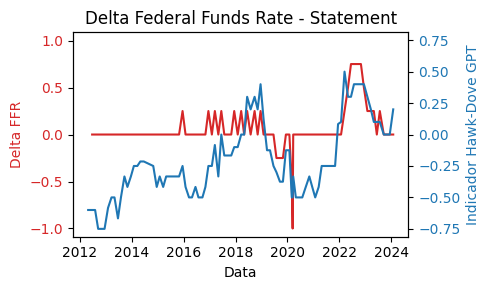

In [9]:
fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.set_title(f'Delta Federal Funds Rate - Statement')
# Plotting the mean values
color = 'tab:red'
ax1.plot(ffr_change.index,ffr_change.values, color=color)
ax1.set_xlabel('Data')
ax1.set_ylabel('Delta FFR', color=color)
ax1.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax1.get_ylim()).max()
ax1.set_ylim(-y_max, y_max)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Plotting the sum values
color = 'tab:blue'
ax2.set_ylabel('Indicador Hawk-Dove GPT', color=color)  # we already handled the x-label with ax1
ax2.plot(statment_pont.index, statment_pont.values, color=color)
ax2.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax2.get_ylim()).max()
ax2.set_ylim(-y_max, y_max)

# ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

fig.tight_layout()  # to ensure that the second y label isn't clipped
fig.savefig(f"result_files/Delta FFR/Statments {prompt_name}.pdf")

plt.show()

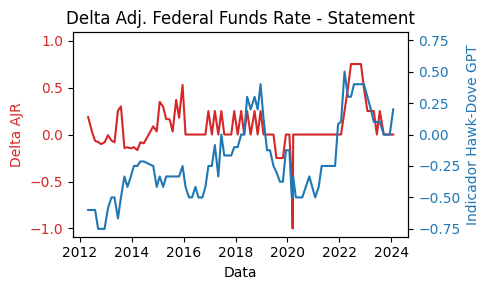

In [10]:
fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.set_title(f'Delta Adj. Federal Funds Rate - Statement')
# Plotting the mean values
color = 'tab:red'
ax1.plot(filtered_FFR['data'], filtered_FFR['adjusted_rate'], color=color)
ax1.set_xlabel('Data')
ax1.set_ylabel('Delta AJR', color=color)
ax1.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax1.get_ylim()).max()
ax1.set_ylim(-y_max, y_max)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Plotting the sum values
color = 'tab:blue'
ax2.set_ylabel('Indicador Hawk-Dove GPT', color=color)  # we already handled the x-label with ax1
ax2.plot(statment_pont.index, statment_pont.values, color=color)
ax2.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax2.get_ylim()).max()
ax2.set_ylim(-y_max, y_max)

fig.tight_layout()  # to ensure that the second y label isn't clipped
fig.savefig(f"result_files/Delta AJR/Statments Adjusted {prompt_name}.pdf")
plt.show()

In [11]:
months = [1,2,3,6]
for month in months:
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.set_title(f'Delta FF 30-day cont. {month} month - Statement')
    # Plotting the mean values
    color = 'tab:red'
    ax1.plot(filtered_FFR['data'], filtered_FFR[f'FFC_{month}m'], color=color)
    ax1.set_xlabel('Data')
    ax1.set_ylabel(f'Delta FFc_{month}m', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    y_max = np.abs(ax1.get_ylim()).max()
    ax1.set_ylim(-y_max, y_max)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    # Plotting the sum values
    color = 'tab:blue'
    ax2.set_ylabel('Indicador Hawk-Dove GPT', color=color)  # we already handled the x-label with ax1
    ax2.plot(statment_pont.index, statment_pont.values, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    y_max = np.abs(ax2.get_ylim()).max()
    ax2.set_ylim(-y_max, y_max)

    fig.tight_layout()  # to ensure that the second y label isn't clipped
    fig.savefig(f"result_files/Delta FFm/{month}m-Statments {prompt_name}.pdf")
    fig.clear()

#     plt.show()

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

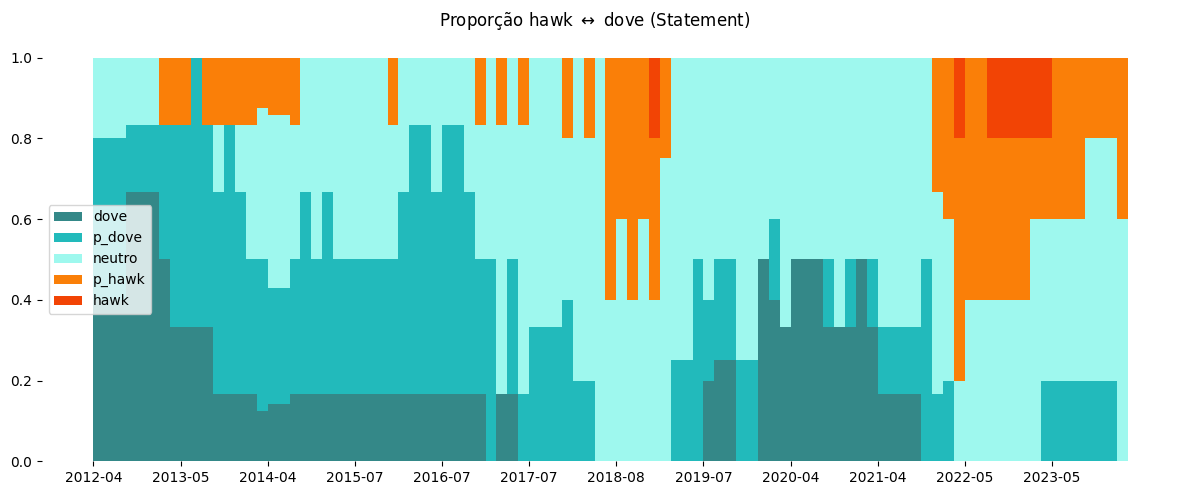

In [12]:
df_prop = df_statment.copy()

categories = {
    'hawk':1,
    'p_hawk':0.5,
    'neutro':0,
    'p_dove':-0.5,
    'dove':-1}

for cat in categories.keys():
    df_prop[cat] = 0
    df_prop.loc[df_prop['classification'] == categories[cat], cat] = 1

df_prop['classification'] = 1
df_prop.drop(columns=['paragrafos','explanation','release'],inplace=True)
df_prop = df_prop.groupby('data').sum()
for cat in categories.keys():
    df_prop[cat] = df_prop[cat] / df_prop['classification']
df_prop.drop(columns=['classification'],inplace=True)


fig, axs = plt.subplots(1, 1, figsize=(12, 5))
fig.suptitle(f'Proporção hawk $\leftrightarrow$ dove (Statement)')
width = 1.0

bar_colors = ['#348888', '#22BABB', '#9EF8EE', '#FA7F08','#F24405']
cats = list(categories.keys())[::-1]
for item in range(len(cats)):
    y = df_prop[cats[item]].to_numpy()
    index = np.arange(0,df_prop.shape[0])
    bottom = 0
    if item > 0:
        bottom = df_prop[cats[0:item]].to_numpy().sum(axis=1)
    axs.bar(index,y,width,bottom=bottom,label=cats[item],linewidth=0,align='edge',color=bar_colors[item])

axs.set_xticks(range(0,df_prop.shape[0],8))
axs.set_xticklabels(df_prop.index.strftime("%Y-%m").to_list()[::8])
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.spines['left'].set_visible(False)
axs.spines['bottom'].set_visible(False)
plt.legend(loc='center left')

fig.tight_layout()  # to ensure that the second y label isn't clipped
fig.savefig(f"result_files/proporcao hawk-dove/statment {prompt_name}.pdf")
# fig.clear()
# plt.show()

## Minutas

In [13]:
file_name_minuta = f'minutas_{prompt_name}'

df_minutas = pd.read_excel(f'{file_name_minuta}.xlsx')

grade_mapping = {
'dovish': -1,
'1. dovish': -1,
'1': -1,

'mostly dovish': -0.5,
'2. mostly dovish': -0.5,
'2': -0.5,

'mostly neutral': 0,
'neutral': 0,
'3. neutral': 0,
'3' : 0,

'mostly hawkish': 0.5,
'4. mostly hawkish': 0.5,
'4' : 0.5,

'hawkish': 1,
'5. hawkish': 1,
'5':1,
}

# Use map function to map grades
df_minutas['classification'] = df_minutas['classification'].astype(str)
df_minutas['classification'] = df_minutas['classification'].str.lower().map(grade_mapping)
df_minutas['data'] = pd.to_datetime(df_minutas['data'])
df_minutas['last_update'] = pd.to_datetime(df_minutas['last_update'].apply(lambda x: x[0:10]))



minutas_pont = df_minutas.groupby('last_update')['classification'].mean()
minutas_pont_std = df_minutas.groupby('last_update')['classification'].std()


# pd.DataFrame({'minutas_pont': minutas_pont}, index=minutas_pont.index).to_parquet(fr"result_files/parquet/{file_name_minuta.split('.')[0]}.parquet")

minutas_pont.to_csv(f"result_files/time_series/Indicador Hawk-dove GPT time series {file_name_minuta}.csv")
minutas_pont.to_excel(f"result_files/time_series/Indicador Hawk-dove GPT time series {file_name_minuta}.xlsx")


In [14]:
df_minutas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            5942 non-null   datetime64[ns]
 1   last_update     5942 non-null   datetime64[ns]
 2   section         5897 non-null   object        
 3   paragrafos      5942 non-null   object        
 4   classification  5942 non-null   float64       
 5   explanation     5942 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 278.7+ KB


In [15]:
df_minutas.isnull().sum()

data               0
last_update        0
section           45
paragrafos         0
classification     0
explanation        0
dtype: int64

In [16]:
unique_dates = df_minutas['last_update'].unique()
delta_FFR = get_diff_federal_funds()

# shadow rate
ffr_delta_min = get_diff_federal_funds()


ffr_delta_min['year_mo'] = pd.to_datetime(
    (ffr_delta_min['date'].dt.year.astype('str')
     + '-' + ffr_delta_min['date'].dt.month.astype('str')),
    format='%Y-%m')


filtered_FFR_minutes = ffr_delta_min[ffr_delta_min['date'].isin(unique_dates)].copy()
filtered_FFR_minutes['delta_rate'] = filtered_FFR_minutes['value'].diff()


#A base do Shadow rate é diferente
shadow_rate = get_shadow().diff().shift(1)
shadow_rate.columns = ['shadow_rate']
filtered_FFR_minutes = filtered_FFR_minutes.join(shadow_rate, on='year_mo')
filtered_FFR_minutes['adjusted_rate'] = filtered_FFR_minutes['delta_rate']
filtered_FFR_minutes.loc[filtered_FFR_minutes['date'] < '2016-01-01', ['adjusted_rate']] = filtered_FFR_minutes.loc[filtered_FFR_minutes['date'] < '2016-01-01','shadow_rate']


df_cor = pd.DataFrame()
df_cor.loc['GPT Statement FFR', 'pearson'] = minutas_pont.corr(filtered_FFR_minutes.set_index('date')['delta_rate'])
df_cor.loc['GPT Statement FFR', 'spearman'] = minutas_pont.corr(filtered_FFR_minutes.set_index('date')['delta_rate'], method='spearman')

df_cor.loc['GPT Statement AJR', 'pearson'] = minutas_pont.corr(filtered_FFR_minutes.set_index('date')['adjusted_rate'])
df_cor.loc['GPT Statement AJR', 'spearman'] = minutas_pont.corr(filtered_FFR_minutes.set_index('date')['adjusted_rate'], method='spearman')


df_cor


,pearson,spearman
GPT Statement FFR,0.625426,0.625423
GPT Statement AJR,0.586603,0.514260


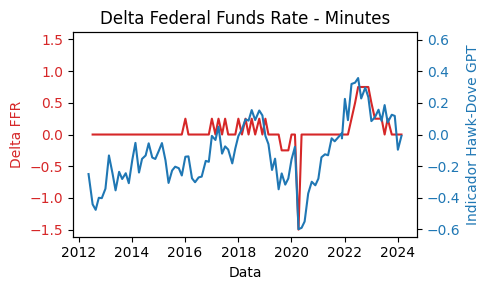

In [17]:
fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.set_title(f'Delta Federal Funds Rate - Minutes')
# Plotting the mean values
color = 'tab:red'
ax1.plot(filtered_FFR_minutes['date'], filtered_FFR_minutes['delta_rate'], color=color)
ax1.set_xlabel('Data')
ax1.set_ylabel('Delta FFR', color=color)
ax1.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax1.get_ylim()).max()
ax1.set_ylim(-y_max, y_max)


ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Plotting the values
color = 'tab:blue'
ax2.set_ylabel('Indicador Hawk-Dove GPT', color=color)  # we already handled the x-label with ax1
ax2.plot(minutas_pont.index, minutas_pont.values, color=color)
ax2.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax2.get_ylim()).max()
ax2.set_ylim(-y_max, y_max)

fig.tight_layout()  # to ensure that the second y label isn't clipped
fig.savefig(f"result_files/Delta FFR/Minutes {prompt_name}.pdf")

plt.show()

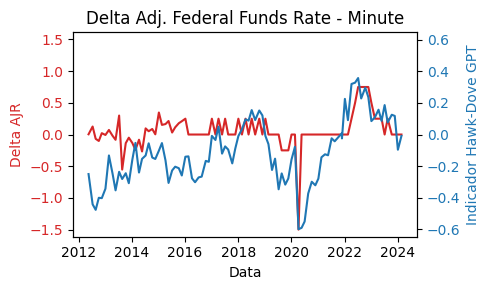

In [18]:
# TODO: Tem que arrumar aqui o gráfico está errado
fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.set_title(f'Delta Adj. Federal Funds Rate - Minute')
# Plotting the mean values
color = 'tab:red'
ax1.plot(filtered_FFR_minutes['date'], filtered_FFR_minutes['adjusted_rate'], color=color)
ax1.set_xlabel('Data')
ax1.set_ylabel('Delta AJR', color=color)
ax1.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax1.get_ylim()).max()
ax1.set_ylim(-y_max, y_max)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Plotting the values
color = 'tab:blue'
ax2.set_ylabel('Indicador Hawk-Dove GPT', color=color)  # we already handled the x-label with ax1
ax2.plot(minutas_pont.index, minutas_pont.values, color=color)
ax2.tick_params(axis='y', labelcolor=color)
y_max = np.abs(ax2.get_ylim()).max()
ax2.set_ylim(-y_max, y_max)

fig.tight_layout()  # to ensure that the second y label isn't clipped
fig.savefig(f"result_files/Delta AJR/Minutes adjusted {prompt_name}.pdf")
plt.show()

In [19]:
df_minutas

,data,last_update,section,paragrafos,classification,explanation
0,2024-01-31,2024-02-21,Annual Organizational Matters5,"1. By unanimous vote, the Committee approved t...",0.0,The paragraph discusses a unanimous vote by th...
1,2024-01-31,2024-02-21,Annual Organizational Matters5,2. Ahead of the vote on policies relating to i...,0.0,The paragraph discusses policies related to in...
2,2024-01-31,2024-02-21,Annual Organizational Matters5,3. Ahead of the vote on the Statement on Longe...,0.0,The paragraph does not provide any specific in...
3,2024-01-31,2024-02-21,Developments in Financial Markets and Open Mar...,4. Developments in Financial Markets and Open ...,0.0,The paragraph discusses developments in financ...
4,2024-01-31,2024-02-21,Developments in Financial Markets and Open Mar...,5. The manager turned next to expectations for...,-0.5,The paragraph suggests that market participant...
...,...,...,...,...,...,...
5937,2012-04-25,2012-05-16,Committee Policy Action,"48. ""Information received since the Federal Op...",-0.5,The paragraph suggests that the economy is exp...
5938,2012-04-25,2012-05-16,Committee Policy Action,"49. Consistent with its statutory mandate, the...",-0.5,The paragraph suggests that the Committee expe...
5939,2012-04-25,2012-05-16,Committee Policy Action,50. To support a stronger economic recovery an...,-1.0,The paragraph strongly expresses the belief th...
5940,2012-04-25,2012-05-16,Committee Policy Action,51. The Committee also decided to continue its...,-1.0,The paragraph indicates that the Committee is ...


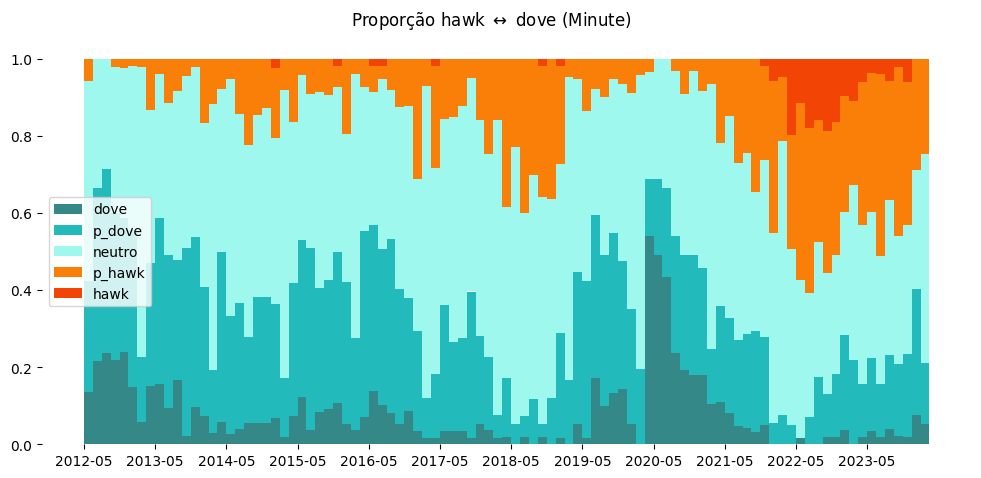

In [21]:
df_prop = df_minutas.copy()

categories = {
    'hawk':1,
    'p_hawk':0.5,
    'neutro':0,
    'p_dove':-0.5,
    'dove':-1}


for cat in categories.keys():
    df_prop[cat] = 0
    df_prop.loc[df_prop['classification'] == categories[cat], cat] = 1

df_prop['classification'] = 1
df_prop.drop(columns=['paragrafos','explanation', 'section', 'data'],inplace=True)
df_prop = df_prop.groupby('last_update').sum()
for cat in categories.keys():
    df_prop[cat] = df_prop[cat] / df_prop['classification']
df_prop.drop(columns=['classification'],inplace=True)


fig, axs = plt.subplots(1, 1, figsize=(12, 5))
fig.suptitle(f'Proporção hawk $\leftrightarrow$ dove (Minute)')
width = 1.0

bar_colors = ['#348888', '#22BABB', '#9EF8EE', '#FA7F08','#F24405']
cats = list(categories.keys())[::-1]
for item in range(len(cats)):
    y = df_prop[cats[item]].to_numpy()
    index = np.arange(0,df_prop.shape[0])
    bottom = 0
    if item > 0:
        bottom = df_prop[cats[0:item]].to_numpy().sum(axis=1)
    axs.bar(index,y,width,bottom=bottom,label=cats[item],linewidth=0,align='edge',color=bar_colors[item])

axs.set_xticks(range(0,df_prop.shape[0],8))
axs.set_xticklabels(df_prop.index.strftime("%Y-%m").to_list()[::8])
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.spines['left'].set_visible(False)
axs.spines['bottom'].set_visible(False)
plt.legend(loc='center left')
fig.savefig(f"result_files/proporcao hawk-dove/minuta {prompt_name}.pdf")
plt.show()